# Day 52/100 - Multiple Kernel Learning (MKL)
**Dataset:** Forest Cover Type (Covertype)  
**Objectif:** Classification multi-classe avec combinaison de noyaux hétérogènes  
**Kernels:** RBF (géographie) + Linear (wilderness) + Linear (soil types)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')

Chargement du dataset Forest Cover Type...
Dataset complet: 581,012 exemples, 54 features, 7 classes

Échantillon utilisé: 5,000 exemples

EDA - ANALYSE EXPLORATOIRE
Valeurs manquantes totales: 0

Statistiques descriptives (features géographiques):


,mean,std,min,25%,50%,75%,max
Elevation,2957.30,281.88,1904.0,2807.0,2995.5,3164.00,3856.0
Aspect,155.11,111.47,0.0,59.0,125.0,258.25,360.0
Slope,14.09,7.52,0.0,9.0,13.0,18.00,47.0
Horizontal_Distance_To_Hydrology,266.64,210.06,0.0,108.0,218.0,384.00,1248.0
Vertical_Distance_To_Hydrology,45.95,57.95,-152.0,7.0,29.0,69.00,455.0
Horizontal_Distance_To_Roadways,2353.36,1546.82,30.0,1107.0,2015.0,3306.25,7039.0
Hillshade_9am,212.46,26.83,56.0,199.0,218.0,232.00,254.0
Hillshade_Noon,223.26,19.69,119.0,213.0,226.0,237.00,254.0
Hillshade_3pm,142.13,38.49,0.0,119.0,143.0,168.00,248.0
Horizontal_Distance_To_Fire_Points,1964.54,1313.63,42.0,1024.0,1697.0,2506.00,6930.0



Distribution des classes (échantillon):
  Classe 1: 1823 (36.5%)
  Classe 2: 2438 (48.8%)
  Classe 3: 308 (6.2%)
  Classe 4: 24 (0.5%)
  Classe 5: 82 (1.6%)
  Classe 6: 149 (3.0%)
  Classe 7: 176 (3.5%)


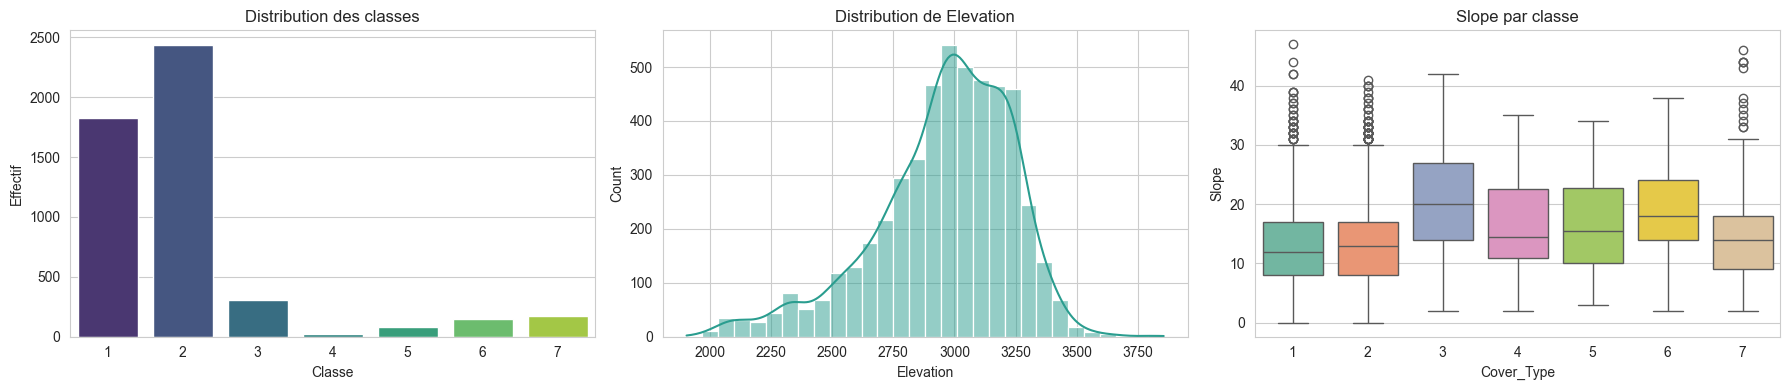

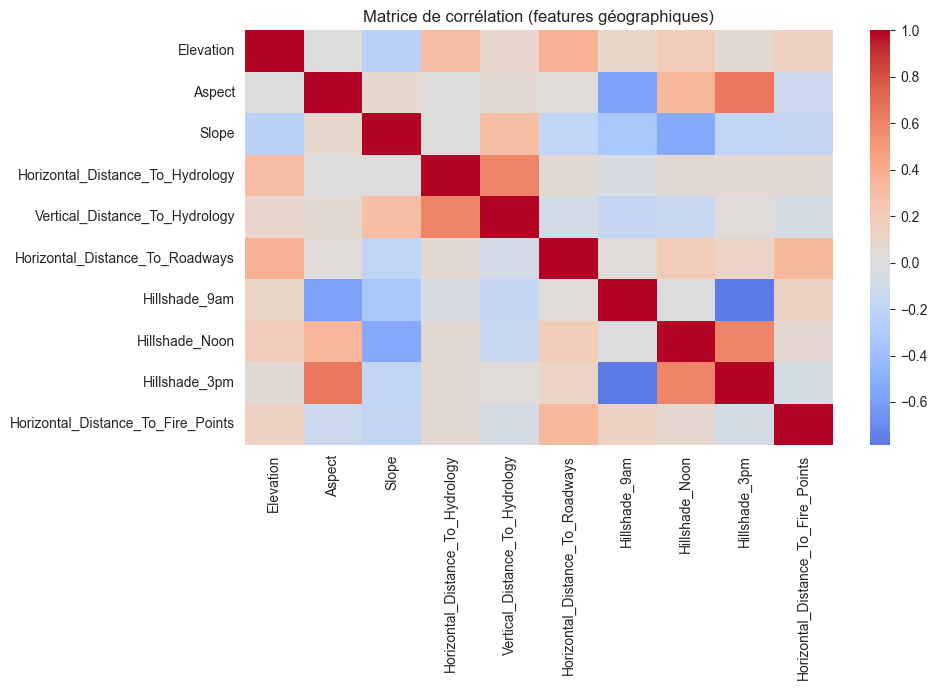


SPLIT TRAIN/VAL/TEST
Train: 3500 (70.0%)
Val:   750 (15.0%)
Test:  750 (15.0%)

Groupes de features:
  - Géographie (continues): 10 features
  - Wilderness (binaires):  4 features
  - Soil types (binaires):  40 features


In [3]:
# Chargement du dataset Covertype
print("Chargement du dataset Forest Cover Type...")
data = fetch_covtype()
X_full = data.data
y_full = data.target
feature_names = data.feature_names

print(f"Dataset complet: {X_full.shape[0]:,} exemples, {X_full.shape[1]} features, {len(np.unique(y_full))} classes")

# Sous-échantillonnage stratifié pour garder un notebook fluide
sample_size = 5000
X_sample, _, y_sample, _ = train_test_split(
    X_full, y_full, train_size=sample_size, random_state=42, stratify=y_full
)
df_sample = pd.DataFrame(X_sample, columns=feature_names)
df_sample['Cover_Type'] = y_sample

print(f"\nÉchantillon utilisé: {sample_size:,} exemples")

# -------- EDA --------
print("\n" + "="*70)
print("EDA - ANALYSE EXPLORATOIRE")
print("="*70)
print(f"Valeurs manquantes totales: {df_sample.isna().sum().sum()}")

geo_cols = feature_names[:10]
print("\nStatistiques descriptives (features géographiques):")
display(df_sample[geo_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

class_dist = pd.Series(y_sample).value_counts().sort_index()
print("\nDistribution des classes (échantillon):")
for cls, count in class_dist.items():
    print(f"  Classe {cls}: {count} ({count/len(y_sample)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Distribution des classes
sns.countplot(x='Cover_Type', data=df_sample, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution des classes')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Effectif')

# 2) Histogramme elevation
sns.histplot(df_sample['Elevation'], bins=30, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Distribution de Elevation')

# 3) Boxplot slope par classe
sns.boxplot(x='Cover_Type', y='Slope', data=df_sample, ax=axes[2], palette='Set2')
axes[2].set_title('Slope par classe')

plt.tight_layout()
plt.show()

# Corrélations sur les variables géographiques
plt.figure(figsize=(10, 7))
corr_geo = df_sample[geo_cols].corr()
sns.heatmap(corr_geo, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (features géographiques)')
plt.tight_layout()
plt.show()

# -------- Split train/val/test = 70/15/15 --------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sample, y_sample, test_size=0.30, random_state=42, stratify=y_sample
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n" + "="*70)
print("SPLIT TRAIN/VAL/TEST")
print("="*70)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X_sample)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X_sample)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X_sample)*100:.1f}%)")

# Groupes de features naturels
geo_indices = list(range(0, 10))
wilderness_indices = list(range(10, 14))
soil_indices = list(range(14, 54))

# Extraction des groupes
X_train_geo = X_train[:, geo_indices]
X_train_wild = X_train[:, wilderness_indices]
X_train_soil = X_train[:, soil_indices]

X_val_geo = X_val[:, geo_indices]
X_val_wild = X_val[:, wilderness_indices]
X_val_soil = X_val[:, soil_indices]

X_test_geo = X_test[:, geo_indices]
X_test_wild = X_test[:, wilderness_indices]
X_test_soil = X_test[:, soil_indices]

# Standardisation des variables continues: fit sur train uniquement
scaler_geo = StandardScaler()
X_train_geo_scaled = scaler_geo.fit_transform(X_train_geo)
X_val_geo_scaled = scaler_geo.transform(X_val_geo)
X_test_geo_scaled = scaler_geo.transform(X_test_geo)

print(f"\nGroupes de features:")
print(f"  - Géographie (continues): {len(geo_indices)} features")
print(f"  - Wilderness (binaires):  {len(wilderness_indices)} features")
print(f"  - Soil types (binaires):  {len(soil_indices)} features")

In [4]:
# Construction des kernels individuels
print("Construction des matrices de kernel...")

# Kernel 1: RBF sur features géographiques
gamma_opt = 0.1
C_opt = 1.0
K1_train = rbf_kernel(X_train_geo_scaled, X_train_geo_scaled, gamma=gamma_opt)
K1_val = rbf_kernel(X_val_geo_scaled, X_train_geo_scaled, gamma=gamma_opt)
K1_test = rbf_kernel(X_test_geo_scaled, X_train_geo_scaled, gamma=gamma_opt)
print(f"  K1 (RBF géographie): train={K1_train.shape}, val={K1_val.shape}")

# Kernel 2: Linéaire sur wilderness areas
K2_train = linear_kernel(X_train_wild, X_train_wild)
K2_val = linear_kernel(X_val_wild, X_train_wild)
K2_test = linear_kernel(X_test_wild, X_train_wild)
print(f"  K2 (Linear wilderness): train={K2_train.shape}, val={K2_val.shape}")

# Kernel 3: Linéaire sur soil types
K3_train = linear_kernel(X_train_soil, X_train_soil)
K3_val = linear_kernel(X_val_soil, X_train_soil)
K3_test = linear_kernel(X_test_soil, X_train_soil)
print(f"  K3 (Linear soil): train={K3_train.shape}, val={K3_val.shape}")

# Normalisation des kernels
K1_train_norm = K1_train / np.trace(K1_train)
K2_train_norm = K2_train / np.trace(K2_train)
K3_train_norm = K3_train / np.trace(K3_train)
K1_val_norm = K1_val / np.trace(K1_train)
K2_val_norm = K2_val / np.trace(K2_train)
K3_val_norm = K3_val / np.trace(K3_train)
K1_test_norm = K1_test / np.trace(K1_train)
K2_test_norm = K2_test / np.trace(K2_train)
K3_test_norm = K3_test / np.trace(K3_train)
print("\nKernels normalisés.")

print("\n" + "="*70)
print("OPTIMISATION MKL (SIMPLE)")
print("="*70)

def mkl_objective(betas, kernels_train, kernels_val, y_train, y_val, C=1.0):
    K_train_combined = sum(beta * K for beta, K in zip(betas, kernels_train))
    K_val_combined = sum(beta * K for beta, K in zip(betas, kernels_val))
    try:
        svm = SVC(kernel='precomputed', C=C, random_state=42)
        svm.fit(K_train_combined, y_train)
        return -svm.score(K_val_combined, y_val)
    except Exception:
        return 1e10

kernels_train = [K1_train_norm, K2_train_norm, K3_train_norm]
kernels_val = [K1_val_norm, K2_val_norm, K3_val_norm]
beta_init = np.array([1/3, 1/3, 1/3])
constraints = {'type': 'eq', 'fun': lambda b: np.sum(b) - 1}
bounds = [(0, 1) for _ in range(3)]

result = minimize(
    mkl_objective,
    beta_init,
    args=(kernels_train, kernels_val, y_train, y_val, C_opt),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 80}
)
beta_opt = np.clip(result.x, 0, 1)
beta_opt = beta_opt / beta_opt.sum()

print(f"\nPoids optimaux β:")
print(f"  β1 (Géographie): {beta_opt[0]:.4f}")
print(f"  β2 (Wilderness):  {beta_opt[1]:.4f}")
print(f"  β3 (Soil types):  {beta_opt[2]:.4f}")

# Performance validation MKL
K_train_mkl = beta_opt[0] * K1_train_norm + beta_opt[1] * K2_train_norm + beta_opt[2] * K3_train_norm
K_val_mkl = beta_opt[0] * K1_val_norm + beta_opt[1] * K2_val_norm + beta_opt[2] * K3_val_norm
svm_mkl_val = SVC(kernel='precomputed', C=C_opt, random_state=42)
svm_mkl_val.fit(K_train_mkl, y_train)
y_val_pred_mkl = svm_mkl_val.predict(K_val_mkl)
acc_val_mkl = accuracy_score(y_val, y_val_pred_mkl)
print(f"Accuracy validation MKL: {acc_val_mkl:.4f}")

# Refit final sur train+val, puis évaluation test
X_trainval_geo = np.vstack([X_train_geo, X_val_geo])
X_trainval_wild = np.vstack([X_train_wild, X_val_wild])
X_trainval_soil = np.vstack([X_train_soil, X_val_soil])
y_trainval = np.concatenate([y_train, y_val])

scaler_geo_final = StandardScaler()
X_trainval_geo_scaled = scaler_geo_final.fit_transform(X_trainval_geo)
X_test_geo_scaled_final = scaler_geo_final.transform(X_test_geo)

K1_trainval = rbf_kernel(X_trainval_geo_scaled, X_trainval_geo_scaled, gamma=gamma_opt)
K1_test_final = rbf_kernel(X_test_geo_scaled_final, X_trainval_geo_scaled, gamma=gamma_opt)
K2_trainval = linear_kernel(X_trainval_wild, X_trainval_wild)
K2_test_final = linear_kernel(X_test_wild, X_trainval_wild)
K3_trainval = linear_kernel(X_trainval_soil, X_trainval_soil)
K3_test_final = linear_kernel(X_test_soil, X_trainval_soil)

K1_trainval_norm = K1_trainval / np.trace(K1_trainval)
K2_trainval_norm = K2_trainval / np.trace(K2_trainval)
K3_trainval_norm = K3_trainval / np.trace(K3_trainval)
K1_test_final_norm = K1_test_final / np.trace(K1_trainval)
K2_test_final_norm = K2_test_final / np.trace(K2_trainval)
K3_test_final_norm = K3_test_final / np.trace(K3_trainval)

K_trainval_mkl = beta_opt[0] * K1_trainval_norm + beta_opt[1] * K2_trainval_norm + beta_opt[2] * K3_trainval_norm
K_test_mkl = beta_opt[0] * K1_test_final_norm + beta_opt[1] * K2_test_final_norm + beta_opt[2] * K3_test_final_norm
svm_mkl = SVC(kernel='precomputed', C=C_opt, random_state=42)
svm_mkl.fit(K_trainval_mkl, y_trainval)
y_pred_mkl = svm_mkl.predict(K_test_mkl)
acc_mkl = accuracy_score(y_test, y_pred_mkl)

print(f"\nMKL optimisé (TEST): {acc_mkl:.4f}")

Construction des matrices de kernel...
  K1 (RBF géographie): train=(3500, 3500), val=(750, 3500)
  K2 (Linear wilderness): train=(3500, 3500), val=(750, 3500)
  K3 (Linear soil): train=(3500, 3500), val=(750, 3500)

Kernels normalisés.

OPTIMISATION MKL (SIMPLE)

Poids optimaux β:
  β1 (Géographie): 0.3333
  β2 (Wilderness):  0.3333
  β3 (Soil types):  0.3333
Accuracy validation MKL: 0.4880

MKL optimisé (TEST): 0.4867


In [5]:
# Résultats détaillés
print("="*70)
print("RÉSULTATS MKL OPTIMISÉ - SPLIT 70/15/15")
print("="*70)
print(f"Hyperparamètres MKL: gamma={gamma_opt}, C={C_opt}")
print(f"Accuracy validation (MKL): {acc_val_mkl:.4f}")
print(f"Accuracy test (MKL): {acc_mkl:.4f}")

print("\n" + "="*70)
print("INTERPRÉTATION DES POIDS β:")
print("="*70)
kernel_names = ['Géographie', 'Wilderness', 'Soil Types']
for i, (name, beta) in enumerate(zip(kernel_names, beta_opt)):
    print(f"  {name:15s}: {beta:.4f} ({beta*100:.1f}%)")

dominant = kernel_names[np.argmax(beta_opt)]
print(f"\n→ La prédiction est dominée par: {dominant}")
print("="*70)

print("\nRapport de classification MKL:")
print(classification_report(y_test, y_pred_mkl, target_names=[f'Cover {i}' for i in range(1, 8)]))

RÉSULTATS MKL OPTIMISÉ - SPLIT 70/15/15
Hyperparamètres MKL: gamma=0.1, C=1.0
Accuracy validation (MKL): 0.4880
Accuracy test (MKL): 0.4867

INTERPRÉTATION DES POIDS β:
  Géographie     : 0.3333 (33.3%)
  Wilderness     : 0.3333 (33.3%)
  Soil Types     : 0.3333 (33.3%)

→ La prédiction est dominée par: Géographie

Rapport de classification MKL:
              precision    recall  f1-score   support

     Cover 1       0.00      0.00      0.00       274
     Cover 2       0.49      1.00      0.65       365
     Cover 3       0.00      0.00      0.00        46
     Cover 4       0.00      0.00      0.00         3
     Cover 5       0.00      0.00      0.00        13
     Cover 6       0.00      0.00      0.00        23
     Cover 7       0.00      0.00      0.00        26

    accuracy                           0.49       750
   macro avg       0.07      0.14      0.09       750
weighted avg       0.24      0.49      0.32       750



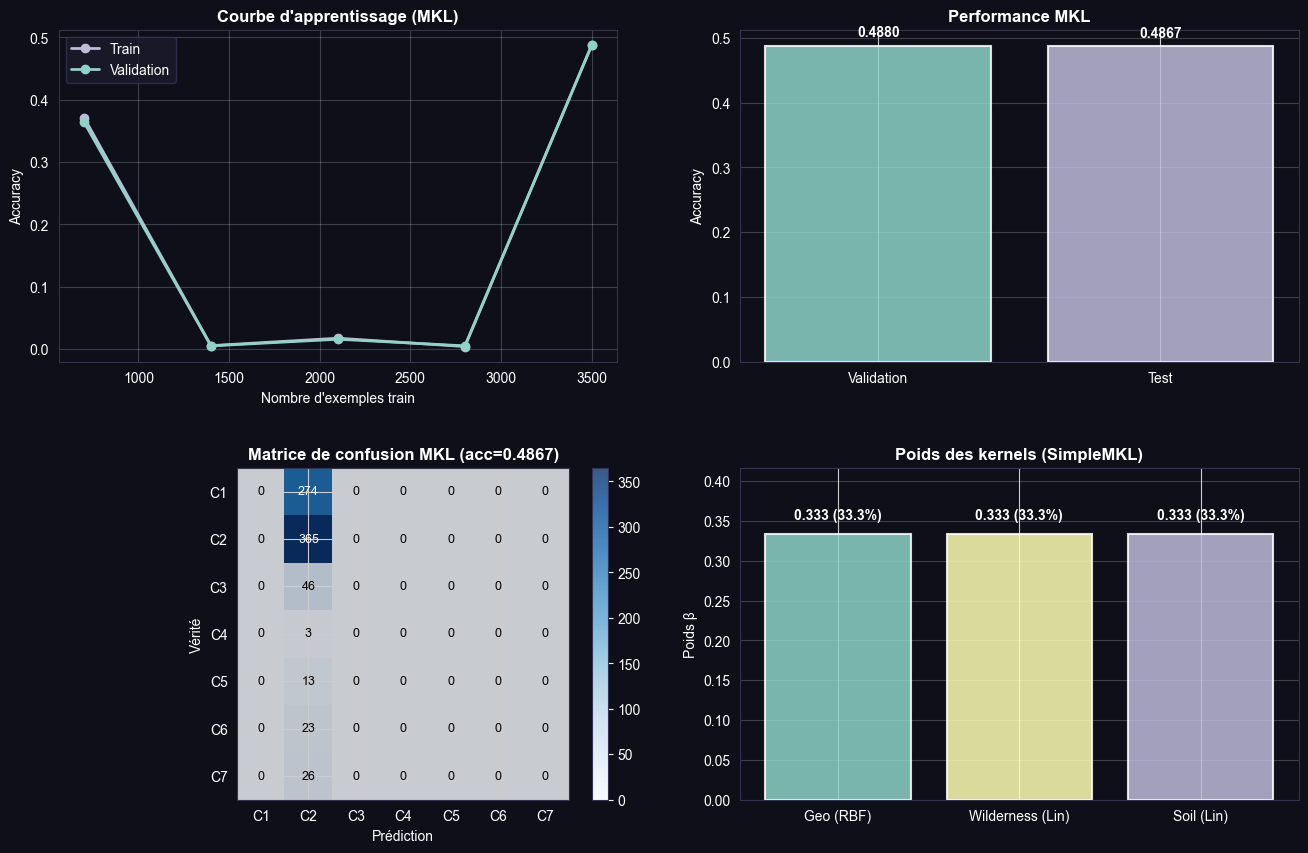

In [6]:
# Visualisation finale (4 graphiques clés)
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.32, wspace=0.22)
colors = plt.cm.Set3.colors

# 1) Courbe d'apprentissage MKL (train vs validation)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#0f0f1a')

train_sizes = np.linspace(0.2, 1.0, 5)
n_train_total = len(y_train)
perm = np.random.RandomState(42).permutation(n_train_total)

train_scores, val_scores, train_sizes_abs = [], [], []
for frac in train_sizes:
    n_sub = max(50, int(frac * n_train_total))
    idx = perm[:n_sub]
    K_train_sub = K_train_mkl[np.ix_(idx, idx)]
    K_val_sub = K_val_mkl[:, idx]
    y_sub = y_train[idx]

    clf = SVC(kernel='precomputed', C=C_opt, class_weight='balanced', random_state=42)
    clf.fit(K_train_sub, y_sub)

    train_scores.append(clf.score(K_train_sub, y_sub))
    val_scores.append(clf.score(K_val_sub, y_val))
    train_sizes_abs.append(n_sub)

ax1.plot(train_sizes_abs, train_scores, marker='o', color=colors[2], linewidth=2, label='Train')
ax1.plot(train_sizes_abs, val_scores, marker='o', color=colors[0], linewidth=2, label='Validation')
ax1.set_title("Courbe d'apprentissage (MKL)", color='white', fontsize=12, weight='bold')
ax1.set_xlabel("Nombre d'exemples train", color='white')
ax1.set_ylabel('Accuracy', color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#1b1b2d', edgecolor='#333355', labelcolor='white')
ax1.grid(True, alpha=0.2, color='white')
for spine in ax1.spines.values():
    spine.set_color('#333355')

# 2) Accuracy MKL (validation vs test)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0f0f1a')
metric_names = ['Validation', 'Test']
metric_values = [acc_val_mkl, acc_mkl]
bars = ax2.bar(range(len(metric_names)), metric_values, color=[colors[0], colors[2]], alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.4f}',
             va='bottom', ha='center', color='white', fontsize=10, weight='bold')
ax2.set_xticks(range(len(metric_names)))
ax2.set_xticklabels(metric_names, color='white')
ax2.set_ylabel('Accuracy', color='white')
ax2.set_title('Performance MKL', color='white', fontsize=12, weight='bold')
ax2.tick_params(colors='white')
ax2.grid(True, axis='y', alpha=0.2, color='white')
for spine in ax2.spines.values():
    spine.set_color('#333355')

# 3) Matrice de confusion MKL
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#0f0f1a')
cm = confusion_matrix(y_test, y_pred_mkl)
im = ax3.imshow(cm, cmap='Blues', alpha=0.8)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax3.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)
ax3.set_xticks(range(7))
ax3.set_yticks(range(7))
ax3.set_xticklabels([f'C{i}' for i in range(1, 8)], color='white')
ax3.set_yticklabels([f'C{i}' for i in range(1, 8)], color='white')
ax3.set_xlabel('Prédiction', color='white')
ax3.set_ylabel('Vérité', color='white')
ax3.set_title(f'Matrice de confusion MKL (acc={acc_mkl:.4f})', color='white', fontsize=12, weight='bold')
for spine in ax3.spines.values():
    spine.set_color('#333355')
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors='white')
cbar.outline.set_edgecolor('#333355')

# 4) Barplot des poids β
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#0f0f1a')
kernel_labels = ['Geo (RBF)', 'Wilderness (Lin)', 'Soil (Lin)']
bars = ax4.bar(range(3), beta_opt, color=colors[:3], alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, beta in zip(bars, beta_opt):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{beta:.3f} ({beta*100:.1f}%)', ha='center', va='bottom',
             color='white', fontsize=10, weight='bold')
ax4.set_xticks(range(3))
ax4.set_xticklabels(kernel_labels, color='white')
ax4.set_ylabel('Poids β', color='white')
ax4.set_title('Poids des kernels (SimpleMKL)', color='white', fontsize=12, weight='bold')
ax4.set_ylim(0, max(beta_opt) * 1.25)
ax4.tick_params(colors='white')
ax4.grid(True, axis='y', alpha=0.2, color='white')
for spine in ax4.spines.values():
    spine.set_color('#333355')

plt.show();